[*********************100%***********************]  1 of 1 completed


valeur fiale= 10552.08023071289


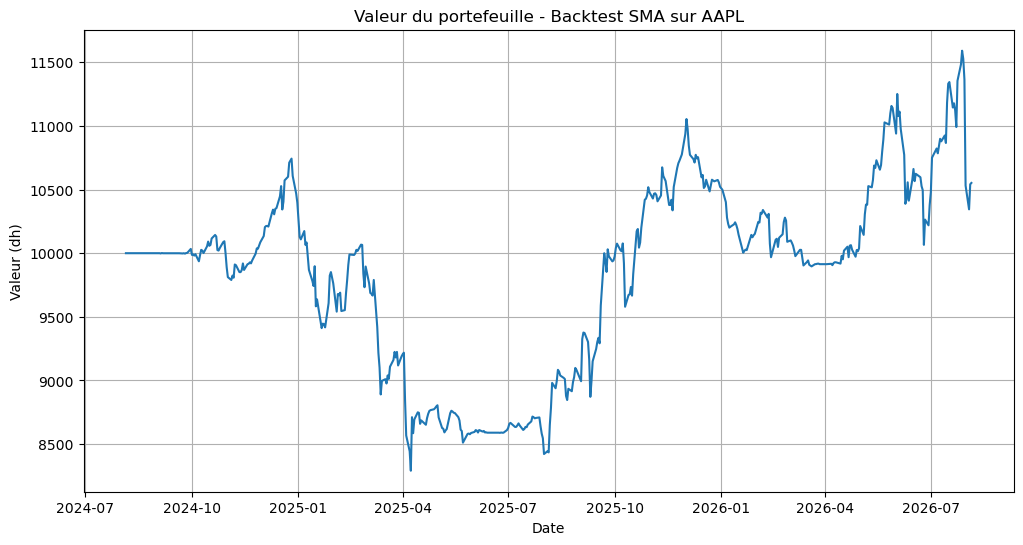

In [5]:
from indicateurs import charger_prix, signal_SMA

prix = charger_prix('AAPL')
signal = signal_SMA(prix, 20)

cash = 10000
position = 0
valeurs = [] #permettra de tracer la courbe de performance.

for date in prix.index:
    prix_jour=prix[date]
    sig=signal[date]
    if sig==1 and cash>=prix_jour:
        position=position+1
        cash=cash-prix_jour
    if sig==-1 and position>0:
        position=position-1
        cash=cash+prix_jour
    valeur=cash+position*prix_jour
    valeurs.append(valeur)

print('valeur fiale=',valeurs[-1])
        
import matplotlib.pyplot as plt
import pandas as pd

courbe = pd.Series(valeurs, index=prix.index)# Reconnecter les valeurs à leurs dates

plt.figure(figsize=(12, 6))
plt.plot(courbe)
plt.title("Valeur du portefeuille - Backtest SMA sur AAPL")
plt.xlabel("Date")
plt.ylabel("Valeur (dh)")
plt.grid(True)
plt.show()


In [6]:
import pandas as pd
from indicateurs import charger_prix, signal_SMA

prix = charger_prix('AAPL')

sma = prix.rolling(20).mean()
signal_brut = (prix > sma).astype(int) # signal AVANT décalage
signal_decale = signal_brut.shift(1) # signal APRÈS décalage (le "sûr")

# On met tout dans un seul tableau
verif = pd.DataFrame({
    'prix': prix,
    'sma': sma,
    'signal_brut': signal_brut,
    'signal_decale': signal_decale,})

print(verif.tail(10))

[*********************100%***********************]  1 of 1 completed

                  prix         sma  signal_brut  signal_decale
Date                                                          
2026-07-23  321.660004  311.492000            1            1.0
2026-07-24  333.019989  314.385500            1            1.0
2026-07-27  336.910004  317.042000            1            1.0
2026-07-28  340.079987  319.959000            1            1.0
2026-07-29  338.190002  322.400500            1            1.0
2026-07-30  333.429993  324.353000            1            1.0
2026-07-31  308.910004  324.367000            0            1.0
2026-08-03  303.420013  323.905000            0            0.0
2026-08-04  309.380005  323.841000            0            0.0
2026-08-05  308.899994  323.616499            0            0.0
